In [1]:
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300
plt.rcParams["hatch.linewidth"] = 0.3
import pandas as pd
import stylia

stylia.set_style("ersilia")
nc = stylia.NamedColors()
import os

In [10]:
datasets = [
    ["CHEMBL", "chembl4649948"],
    ["CHEMBL", "chembl4659961"],
    ["TDC", "ames"],
    ["TDC", "bbb_martins"],
    ["TDC", "bioavailability_ma"],
    ["TDC", "carcinogens_lagunin"],
    ["TDC", "clintox"],
    ["TDC", "cyp1a2_veith"],
    ["TDC", "cyp2c19_veith"],
    ["TDC", "cyp2c9_substrate_carbonmangels"],
    ["TDC", "cyp2c9_veith"],
    ["TDC", "cyp2d6_substrate_carbonmangels"],
    ["TDC", "cyp2d6_veith"],
    ["TDC", "cyp3a4_substrate_carbonmangels"],
    ["TDC", "cyp3a4_veith"],
    ["TDC", "dili"],
    ["TDC", "herg"],
    ["TDC", "hia_hou"],
    ["TDC", "pgp_broccatelli"],
    ["TDC", "skin_reaction"],
    ["GARDP", "abaumannii_inh_avg_bin"],
    ["GARDP", "kpneumoniae_atcc_43816_inh_avg_bin"],
    ["GARDP", "kpneumoniae_ecl8_inh_avg_bin"],
    ["GARDP", "kpneumoniae_nctc_13438_inh_avg_bin"],
]

PATH_TO_EOSBENCH_RESULTS = os.path.join("../results/eosbench")

In [11]:
# Create results df
files = sorted(os.listdir(PATH_TO_EOSBENCH_RESULTS))
df = pd.concat(
    [pd.read_csv(os.path.join(PATH_TO_EOSBENCH_RESULTS, f)) for f in files],
    ignore_index=True,
)
df["source"] = [i.upper() for i in df["source"]]

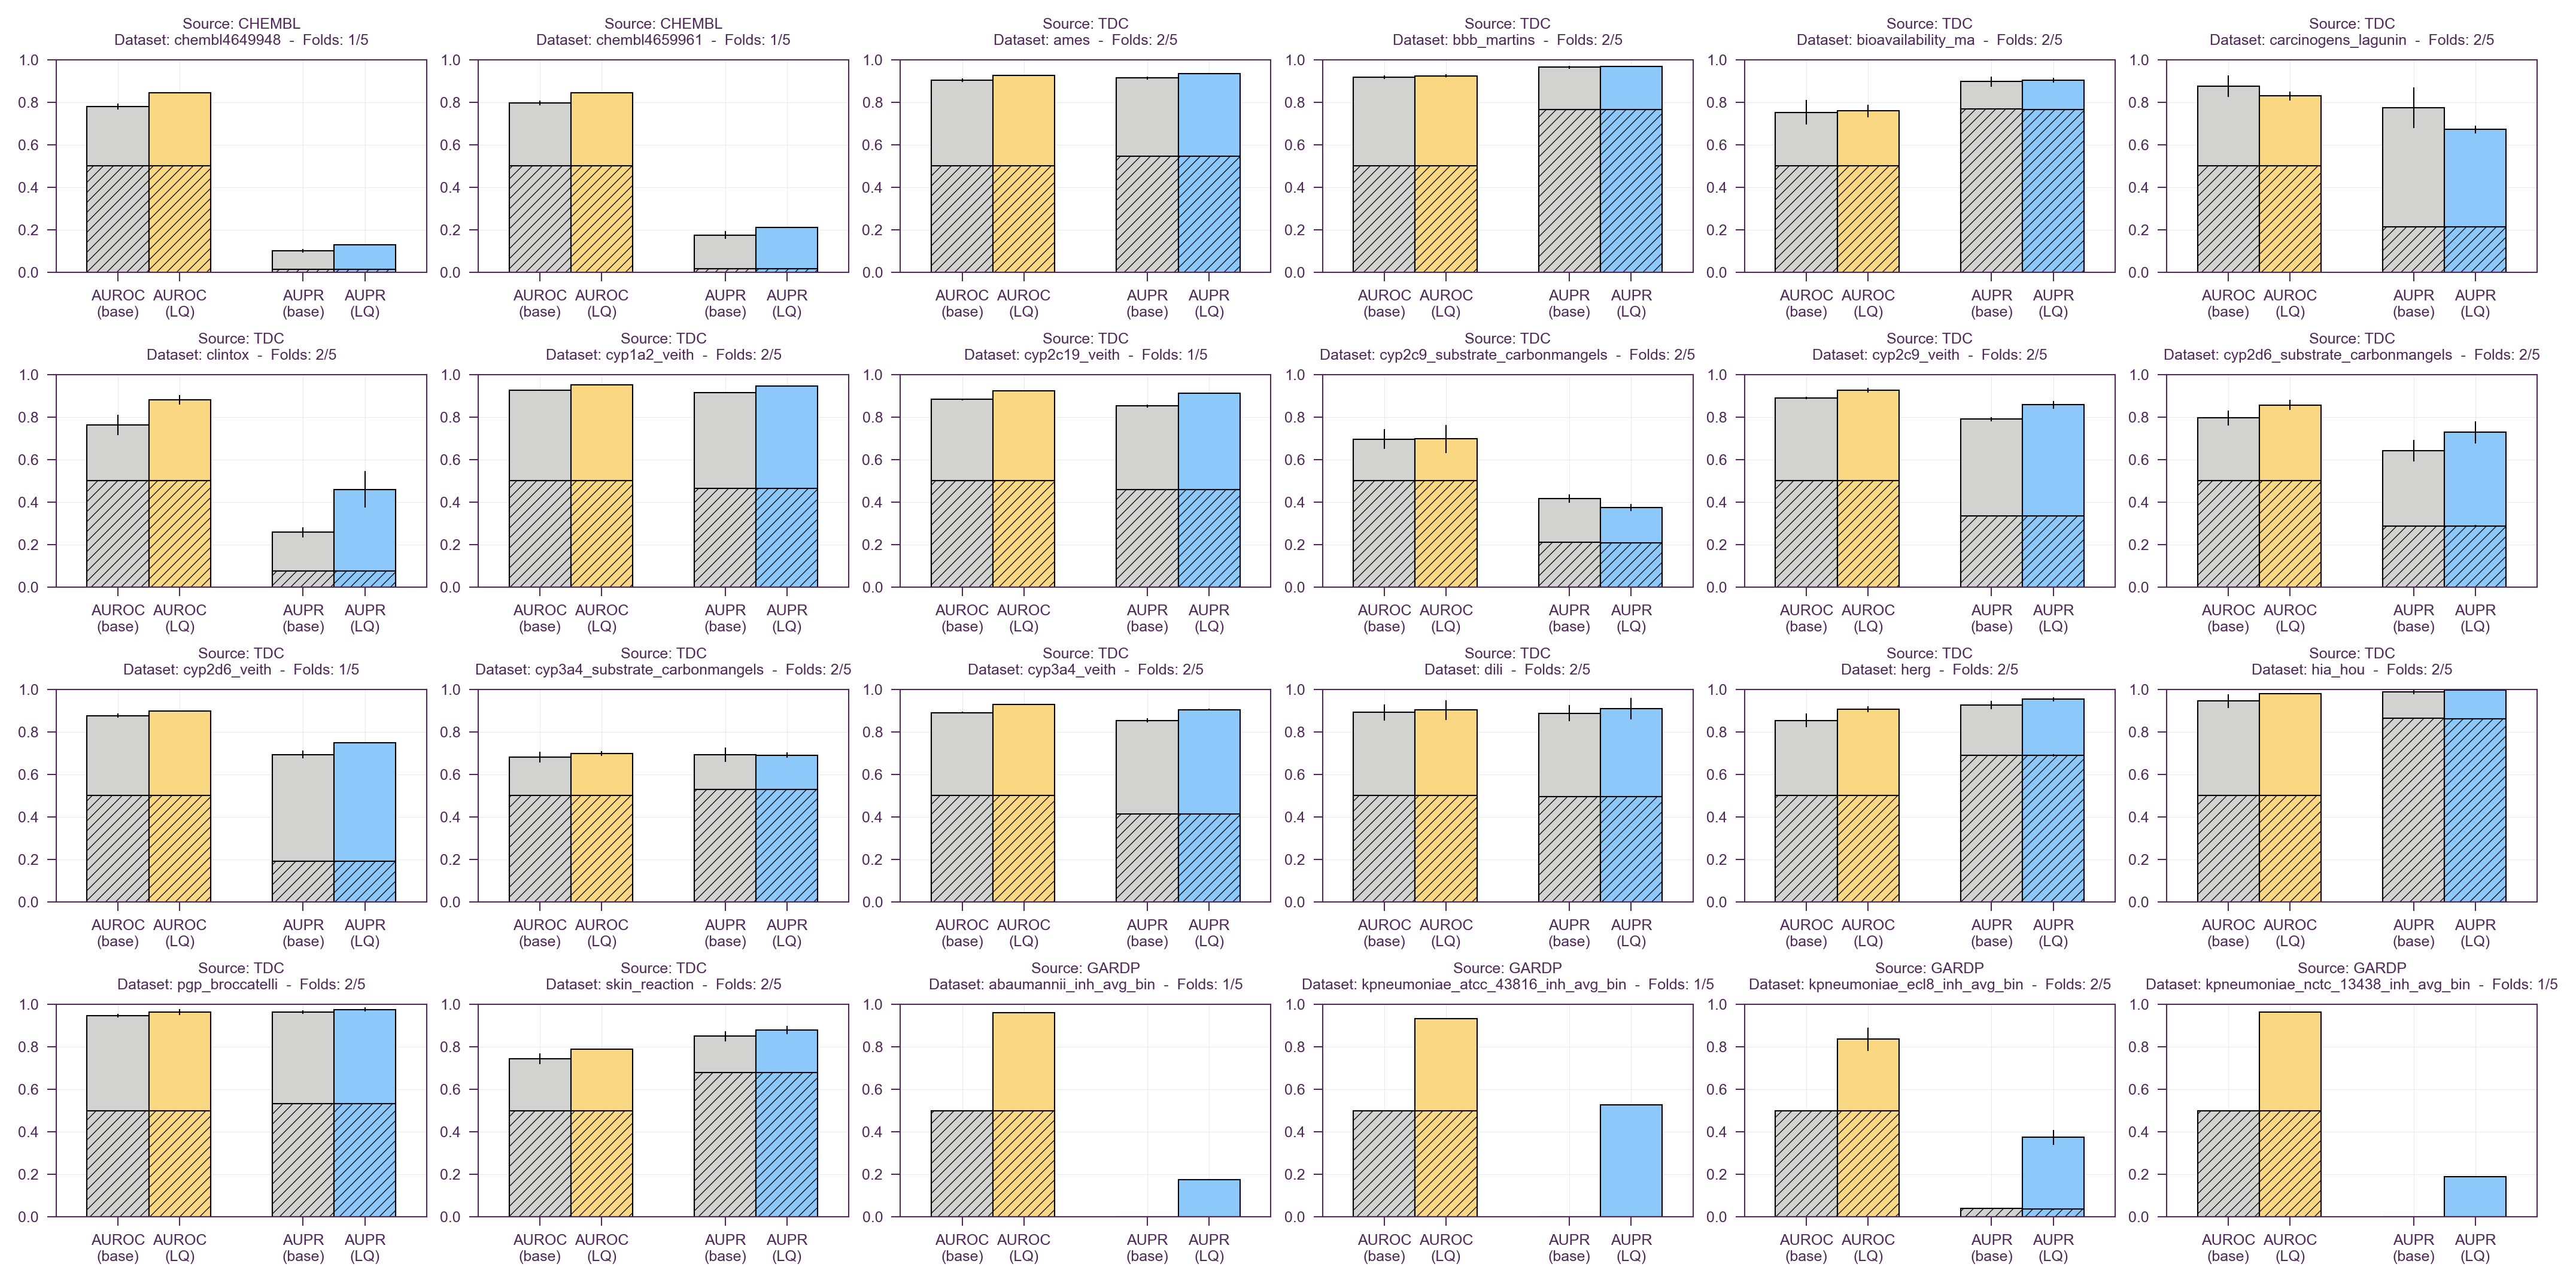

In [12]:
stylia.set_format("print")

fig, axs = stylia.create_figure(4, 6, width=2, height=1)

for source, dataset in datasets:
    # Get values
    df_subset = df[(df["dataset"] == dataset) & (df["source"] == source)]

    # Prepare plot
    ax = axs.next()
    ax.set_title(f"Source: {source}\nDataset: {dataset}  -  Folds: {len(df_subset)}/5")
    ax.set_ylim([0, 1])
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_xlim([0, 6])
    w = 1
    x = [1, 2, 4, 5]
    ax.set_xticks(x)
    ax.set_xticklabels(["AUROC\n(base)", "AUROC\n(LQ)", "AUPR\n(base)", "AUPR\n(LQ)"])

    try:
        auroc_mean = df_subset["auroc"].mean()
        auroc_std = df_subset["auroc"].std()
        aupr_mean = df_subset["aupr"].mean()
        aupr_std = df_subset["aupr"].std()
        auroc_ref_mean = df_subset["auroc_ref_mean"].tolist()[0]
        auroc_ref_std = df_subset["auroc_ref_std"].tolist()[0]
        aupr_ref_mean = df_subset["aupr_ref_mean"].tolist()[0]
        aupr_ref_std = df_subset["aupr_ref_std"].tolist()[0]
        y1 = [auroc_ref_mean, auroc_mean, aupr_ref_mean, aupr_mean]
        y2 = [auroc_ref_std, auroc_std, aupr_ref_std, aupr_std]
        aupr_baseline_mean = df_subset["aupr_baseline"].mean()
        aupr_baseline_std = df_subset["aupr_baseline"].std()
        aupr_baseline_ref = (
            df_subset["n_pos_train"].tolist()[0] + df_subset["n_pos_test"].tolist()[0]
        ) / (df_subset["n_train"].tolist()[0] + df_subset["n_test"].tolist()[0])
        y_baseline = [0.5, 0.5, aupr_baseline_ref, aupr_baseline_mean]
        y_baseline_std = [0, 0, 0, aupr_baseline_std]
        colors = [nc.gray, nc.yellow, nc.gray, nc.blue]

        # Plot
        for i in range(len(x)):
            ax.bar(x[i], y1[i], color=colors[i], width=w, ec="k", lw=0.5)
            ax.vlines(x[i], y1[i] - y2[i], y1[i] + y2[i], color="k", lw=0.5)
            ax.bar(
                x[i],
                y_baseline[i],
                color=colors[i],
                width=w,
                ec="k",
                lw=0.5,
                hatch="/" * 6,
            )
            ax.vlines(
                x[i],
                y_baseline[i] - y_baseline_std[i],
                y_baseline[i] + y_baseline_std[i],
                color="k",
                lw=0.5,
            )

    except:
        pass

plt.tight_layout()
plt.show()

In [5]:
df

,source,dataset,fold,n_folds,n_train,n_test,n_pos_train,n_neg_train,n_pos_test,n_neg_test,auroc,aupr,aupr_baseline,aupr_ratio,auroc_ref_mean,auroc_ref_std,aupr_ref_mean,aupr_ref_std
0,CHEMBL,chembl4649948,0,5,69271,17318,1015,68256,253,17065,0.8434,0.1283,0.0146,8.7847,0.7782,0.0141,0.1007,0.0095
1,CHEMBL,chembl4659961,0,5,42532,10633,719,41813,179,10454,0.8435,0.2111,0.0168,12.5390,0.7956,0.0107,0.1749,0.0189
2,GARDP,abaumannii_inh_avg_bin,0,5,131227,32807,133,131094,30,32777,0.9605,0.1741,0.0009,190.3992,0.0000,0.0000,0.0000,0.0000
3,GARDP,kpneumoniae_atcc_43816_inh_avg_bin,0,5,115485,28872,91,115394,15,28857,0.9332,0.5279,0.0005,1016.0485,0.0000,0.0000,0.0000,0.0000
4,GARDP,kpneumoniae_ecl8_inh_avg_bin,0,5,8714,2179,345,8369,85,2094,0.7969,0.3487,0.0390,8.9401,0.0000,0.0000,0.0000,0.0000
5,GARDP,kpneumoniae_ecl8_inh_avg_bin,1,5,8714,2179,357,8357,73,2106,0.8741,0.3993,0.0335,11.9194,0.0000,0.0000,0.0000,0.0000
6,GARDP,kpneumoniae_nctc_13438_inh_avg_bin,0,5,138478,34620,118,138360,34,34586,0.9645,0.1900,0.0010,193.4249,0.0000,0.0000,0.0000,0.0000
7,TDC,ames,0,5,5822,1456,3179,2643,795,661,0.9239,0.9340,0.5460,1.7106,0.9029,0.0079,0.9132,0.0081
8,TDC,ames,1,5,5822,1456,3179,2643,795,661,0.9253,0.9361,0.5460,1.7145,0.9029,0.0079,0.9132,0.0081
9,TDC,bbb_martins,0,5,1631,408,1248,383,312,96,0.9199,0.9667,0.7647,1.2641,0.9168,0.0089,0.9639,0.0064


In [6]:
y2

[0.0, np.float64(nan), 0.0, np.float64(nan)]